<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [ ]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `load_boston()` from `sklearn.datasets`
# Load dataset and convert to DataFrame:
# Add your code here:
'''
Note:load_boston() is throwing error in new version of sklearn so used fetch_openml.
'''
#Fetch Boston dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Get DataFrame
boston_housing_data = boston.frame

In [ ]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.
# Add your code here:

# Display first few rows of dataset
print('Few rows of dataset:\n',boston_housing_data.head())

Few rows of dataset:
       CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
print('Information of dataset:\n')
print(boston_housing_data.info())
print('\nStatistical Summary of Dataset:\n',boston_housing_data.describe().round(2))

Information of dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB
None

Statistical Summary of Dataset:
          CRIM      ZN   INDUS     NOX      RM     AGE     DIS     TAX  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean  

# Insights:
The dataset contains mostly continuous numerical features. However, CHAS is a binary categorical feature indicating proximity to the Charles River, and RAD is a discrete ordinal feature representing highway accessibility. The remaining variables are continuous in nature.

Encoding is not required for Random Forest model since it is a tree-based model that can handle numerical and categorical like features internally. In this dataset, CHAS and RAD are already numeric, so no additional encoding was necessary.

In [ ]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
#Check missing values
print('Missing values:\n',boston_housing_data.isnull().sum())

Missing values:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


# Insight:
No missing values so dataset is clean and is not required to handle any missing value.

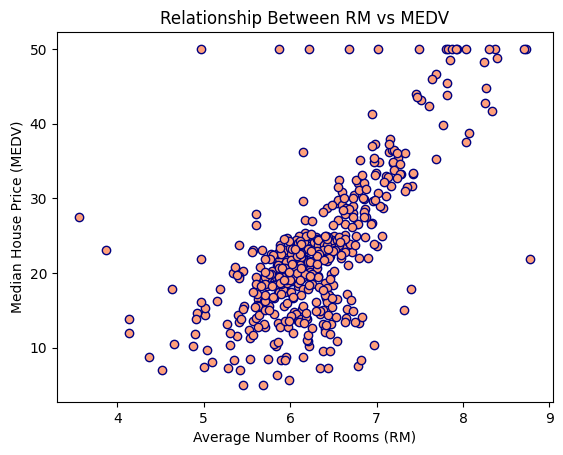

In [ ]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').

# Add your code here:
'''
Note: Other features vs target variable plots are shown in the next cell.
'''
# Create scatter plot
plt.scatter(boston_housing_data['RM'],boston_housing_data['MEDV'],color='lightsalmon',edgecolors='navy')
#Add title and label of axis
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Price (MEDV)')
plt.title('Relationship Between RM vs MEDV')
plt.show()#display plot

In [ ]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:
'''
Note: To analyze the relationship between independent features and the target variable, scatter plots were generated using a loop and subplots for
efficient visualization.
'''
#Create function to automate scatter plots for all features vs MEDV
def scatter_plots_all_features(df, features,target='MEDV'):
    # take colors
    colors = ['lightcyan', 'pink', 'orange', 'limegreen']
    # set plot size
    plt.figure(figsize=(15, 15))
    # loop through features
    for i, feature in enumerate(features):
        plt.subplot(3, 3, i + 1)  # create subplot
        # Create scatter plot
        plt.scatter(df[feature],df[target],color=colors[i],edgecolors='navy')
        # Add label of axis and title
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
    plt.tight_layout()#tight layout plot
    plt.show()#display plot

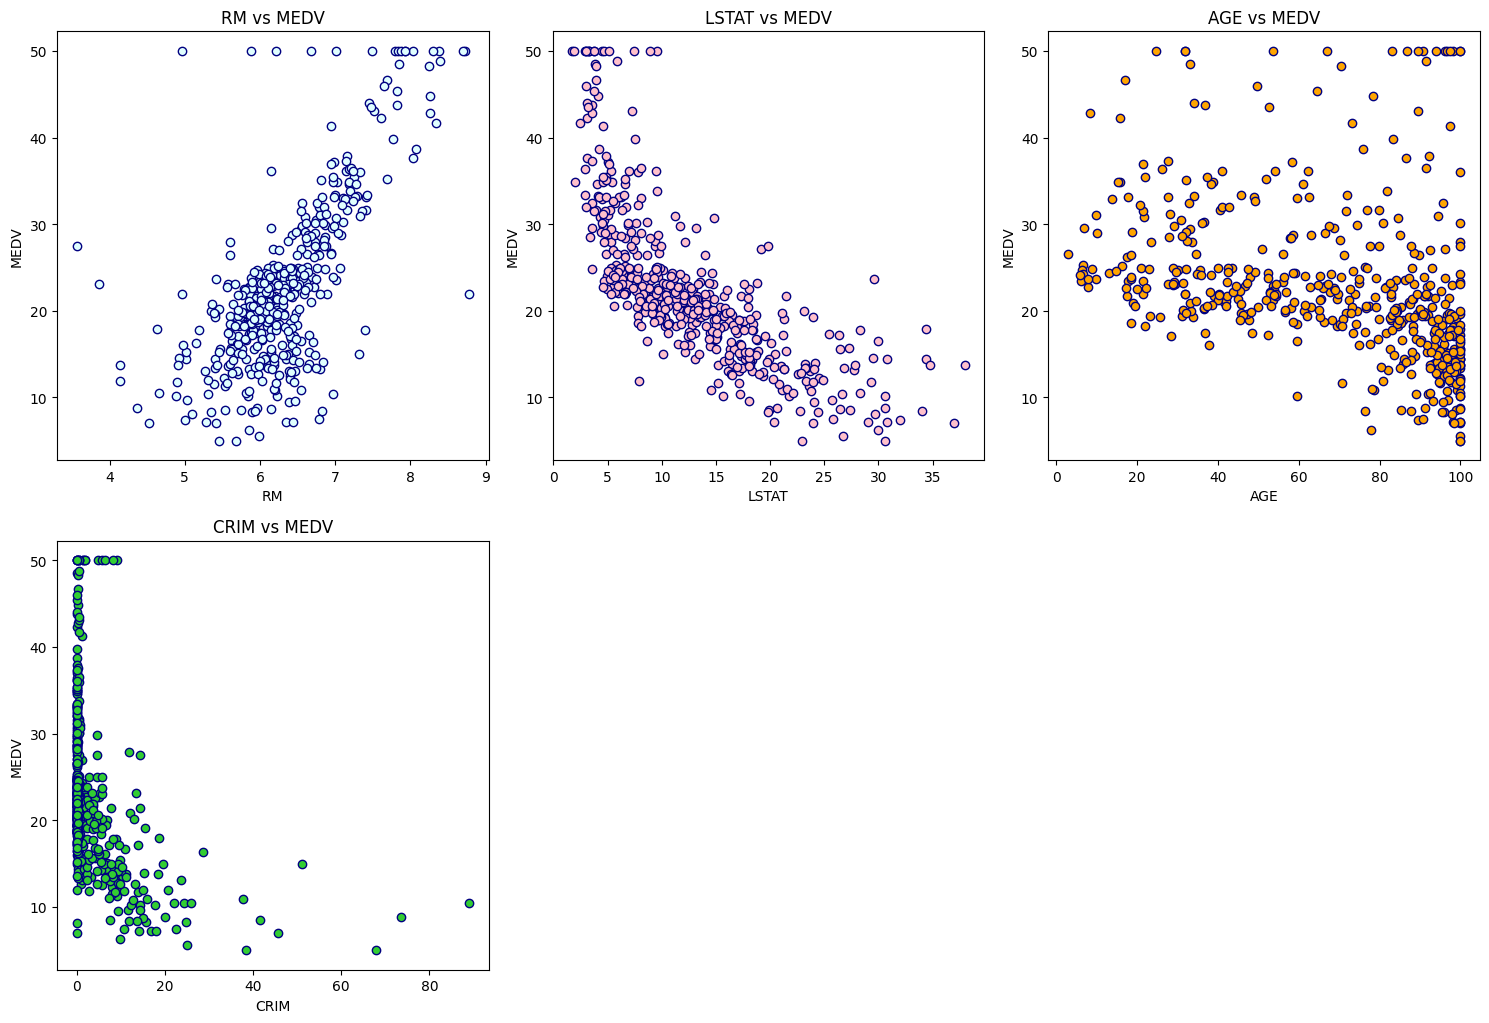

In [ ]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Example: ['RM', 'LSTAT', 'AGE', 'CRIM']
# Target: 'MEDV'
# Add your code here:
'''
Note: Only 4 features are mentioned so used them only for creation of plot.
'''
Features= ['RM', 'LSTAT', 'AGE', 'CRIM'] #selected features
#call function
scatter_plots_all_features(boston_housing_data, Features,target='MEDV')

# Key Insights:

*   The strong positive correlation between RM (average number of rooms) and MEDV shows the number of rooms increases, house prices increase significantly.
*   Houses with RM > 7 tend to have higher price range (above 30-50).
*   Larger houses (more rooms) are generally more expensive.
*   LSTAT shows a very strong negative correlation with MEDV as LSTAT increases, house prices decrease sharply.
*   High LSTAT values (poor socio-economic status areas) mostly correspond to low house prices (below 20).
*   Socio-economic status is one of the strongest predictors of house price.
*   AGE shows a weak negative relationship with MEDV as older houses (AGE close to 100) tend to have slightly lower prices, but the pattern is not very strong.
*   Age of property has limited influence compared to economic factors.
*   Higher crime rates generally correspond to lower house prices.
*   The visualization of CRIM vs MEDV shows the relationship is not perfectly linear and has many outliers.Some low-crime areas still show varied prices.  Crime rate affects price negatively but is less consistent than RM or LSTAT.

In [ ]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:

# Define features (X) and target (y)
X = boston_housing_data.drop('MEDV', axis=1)#independent variables
y = boston_housing_data['MEDV']#target variable

# Split dataset as 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Hint: Use either `DecisionTreeRegressor` or `RandomForestRegressor` from `sklearn.tree` or `sklearn.ensemble`.
# Define your regression model here:

# Create RandomForestRegressor model with random_state=42, which fixes the randomness of data and ensures reproducibility of results
rf_model = RandomForestRegressor(random_state=42)

In [ ]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:
# Train model on training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics on test data
rmse = mean_squared_error(y_test, y_pred)#calculate the average prediction error
r2 = r2_score(y_test, y_pred)#calculate how well the model explains variance in the data

print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

RMSE: 7.9
R² Score: 0.89


# Interpretation:

RMSE = 7.9 means the model's predictions are off by about 7.9 units (7,900 dollars since MEDV is in 1000s dollars) on average. Considering the target (MEDV) ranges roughly from 5 to 50, this error is relatively moderate and acceptable for a real-world dataset. The model shows good predictive accuracy, but there is still some deviation between actual and predicted values.

R2 Score = 0.89 shows that the model explains about 89% of the variance in house prices, meaning it captures most of the patterns in the data. Only about 11% of the variation is not explained by the model, which indicates a strong performing model with high predictive power.

In [ ]:
# Perform parameter tuning on the model if needed to improve the performance of your model.
# Add your parameter tuning code here:

# Define hyperparameters
param_grid = {
    # Number of trees in the forest, where 50=fast,basic performance check,100=standard default (balanced) and 200=better accuracy but slower
    'n_estimators': [50, 100, 200],
    # Maximum depth of each decision tree to prevent overfitting,where None=fully grown trees (can overfit),10=shallow tree (simple model),20=moderate complexity
    # and 30=deeper tree (more complex patterns)
    'max_depth': [None, 10, 20, 30],
    # Minimum number of samples required to split a node, where 2=very flexible tree (can overfit),5=moderate restriction and 10=stronger regularization (less overfitting)
    'min_samples_split': [2, 5, 10]}

# GridSearchCV used to tune hyperparameters such as number of trees, depth and split criteria
grid_search = GridSearchCV(estimator=rf_model,# Random Forest machine learning model to be optimized
                           param_grid=param_grid,# Dictionary of hyperparameters
                           cv=5, # 5-fold cross-validation where training data is split into 5 parts to ensure reliable model evaluation
                           scoring='r2',  # Evaluation metric used to compare models
                           n_jobs=-1  # Uses all available CPU cores to speed up training
                           )

# Fit model on train data
grid_search.fit(X_train, y_train)

# Best model creation
best_model = grid_search.best_estimator_ #retrieves the best-performing model data from GridSearchCV based on the highest cross-validation R2 score

print("Best Parameters:", grid_search.best_params_)#display best hyperparameter values

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


# Insight:
Model performs best with full tree depth (no restriction), low split threshold (captures more detail) and 100 trees (balanced performance). The dataset benefits from a complex model that captures nonlinear relationships.

In [ ]:
# Predict on the test set and calculate the evaluation metrics:
# Predictions with best model
y_pred_tuned = best_model.predict(X_test)

# Calculate evaluation metrics
rmse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned RMSE:", round(rmse_tuned,2))
print("Tuned R² Score:", round(r2_tuned,2))

Tuned RMSE: 7.9
Tuned R² Score: 0.89


# Model comparision:
Tuned model performance is same as base model (R2 = 0.89, RMSE = 7.9)

The default Random Forest was already near optimal and hyperparameter tuning did not significantly improve performance.

In [ ]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: Use hypothetical or randomly generated values for the features.
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12
# Add your prediction code here:

# New house data
new_data = pd.DataFrame([{'CRIM': 0.2,'ZN': 12.5,'INDUS': 7.07,'CHAS': 0,'NOX': 0.5,'RM': 6.5,'AGE': 68,'DIS': 4.0,'RAD': 2,'TAX': 250,'PTRATIO': 17,'B': 400,'LSTAT': 12}])

# Predict using trained best model
prediction = best_model.predict(new_data)

print("Predicted House Price (in $1000s):", round(prediction[0],2))

Predicted House Price (in $1000s): 22.19


The model predicts that the house price is 22.19 x 1000 = $22,190, based on the given input features.

# Conclusion:

The Random Forest model successfully predicts Boston housing prices with high accuracy (R2 = 0.89). The results show that socio-economic factors such as LSTAT and RM are the most influential features. Since hyperparameter tuning did not significantly improve performance, the baseline model is already well-optimized for this dataset.